Mini Project: Colorizing Old B&W Images: color old black and white images to colorful images

Loading model...


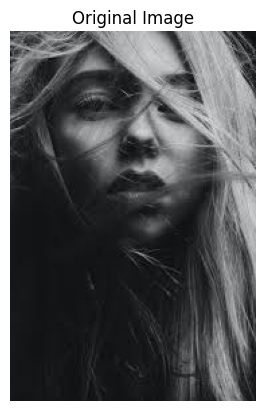

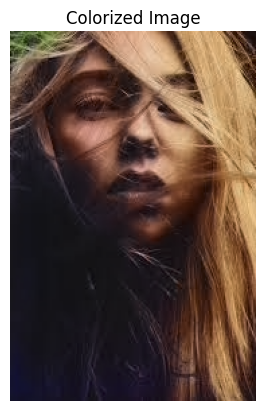

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("Loading model...")

# Load model
net = cv2.dnn.readNetFromCaffe(
    'colorization_deploy_v2.prototxt',
    'colorization_release_v2.caffemodel'
)

# Load points
pts = np.load('pts_in_hull.npy')

# Set model layers
class8 = net.getLayerId("class8_ab")
conv8 = net.getLayerId("conv8_313_rh")

pts = pts.transpose().reshape(2, 313, 1, 1)
net.getLayer(class8).blobs = [pts.astype("float32")]
net.getLayer(conv8).blobs = [np.full([1, 313], 2.606, dtype="float32")]

# Read image
image = cv2.imread('image.jpg')
scaled = image.astype("float32") / 255.0

# Convert to LAB
lab = cv2.cvtColor(scaled, cv2.COLOR_BGR2LAB)

# Resize
resized = cv2.resize(lab, (224, 224))

# Extract L channel
L = cv2.split(resized)[0]
L -= 50

# Predict colors
net.setInput(cv2.dnn.blobFromImage(L))
ab = net.forward()[0, :, :, :].transpose((1, 2, 0))

# Resize back
ab = cv2.resize(ab, (image.shape[1], image.shape[0]))

# Merge channels
L = cv2.split(lab)[0]
colorized = np.concatenate((L[:, :, np.newaxis], ab), axis=2)

# Convert to BGR
colorized = cv2.cvtColor(colorized, cv2.COLOR_LAB2BGR)
colorized = np.clip(colorized, 0, 1)
colorized = (255 * colorized).astype("uint8")

# Show output
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

plt.imshow(cv2.cvtColor(colorized, cv2.COLOR_BGR2RGB))
plt.title("Colorized Image")
plt.axis("off")
plt.show()

In [ ]:
!jupyter nbconvert --to html "/content/DL_(Mini_Project).ipynb"

[NbConvertApp] Converting notebook /content/DL_(Mini_Project).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 563583 bytes to /content/DL_(Mini_Project).html
